# Visual Sentiment Analysis

This notebook visualizes Reddit sentiment data through various charts and plots.

Saved plot to S&P Updated/posts_comments_by_year.png


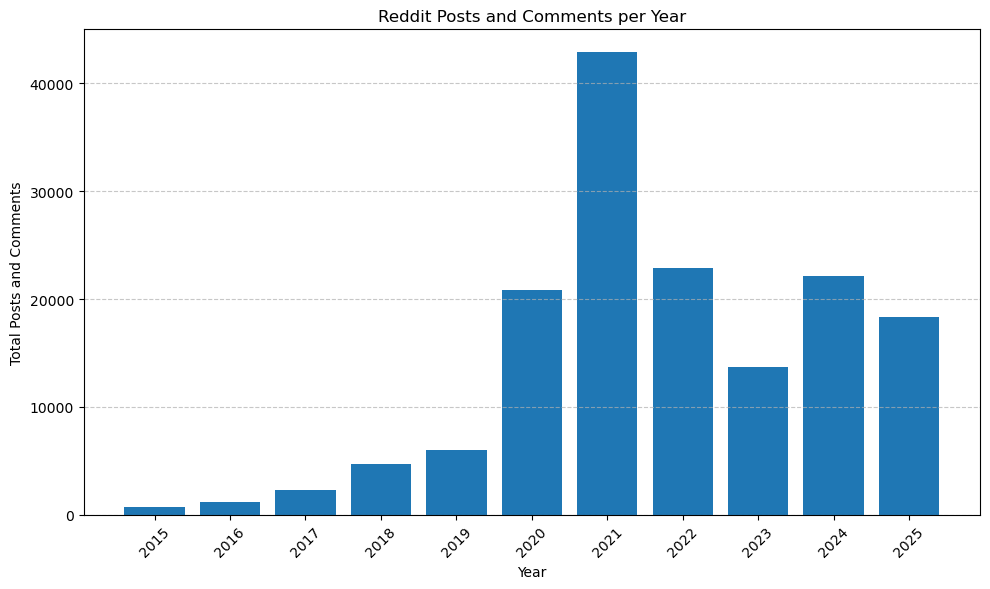


Posts and Comments per Year:
    year  count
0   2015    673
1   2016   1221
2   2017   2336
3   2018   4728
4   2019   6040
5   2020  20804
6   2021  42878
7   2022  22893
8   2023  13669
9   2024  22176
10  2025  18322


In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Specify the CSV file
csv_file = 'sp100.csv'

## Posts and Comments by Year

Visualize the distribution of Reddit posts and comments over time.

Saved posts plot to S&P Updated/posts_by_year.png


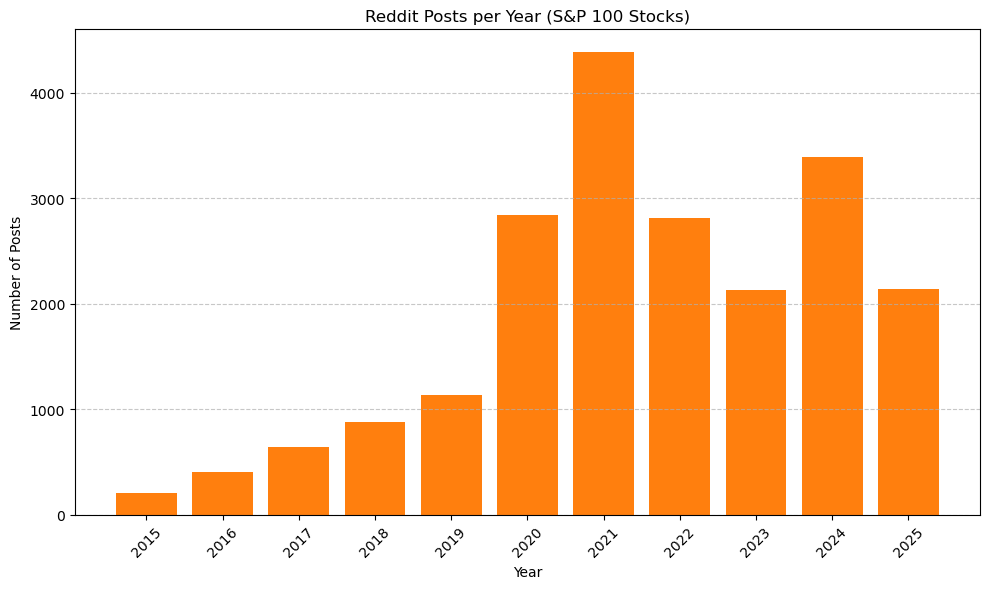

Saved comments plot to S&P Updated/comments_by_year.png


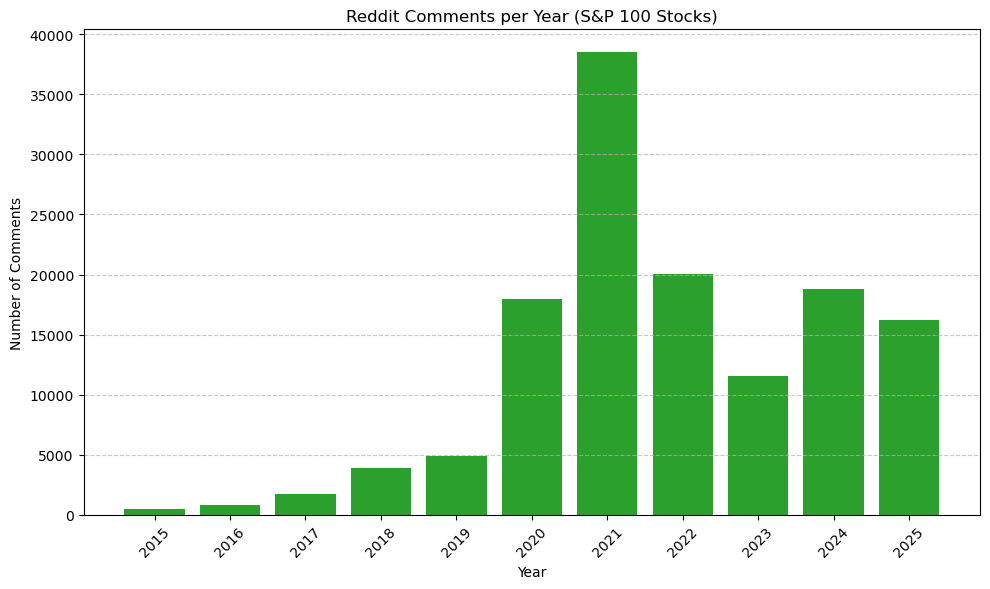

Saved combined plot to S&P Updated/posts_comments_combined_by_year.png


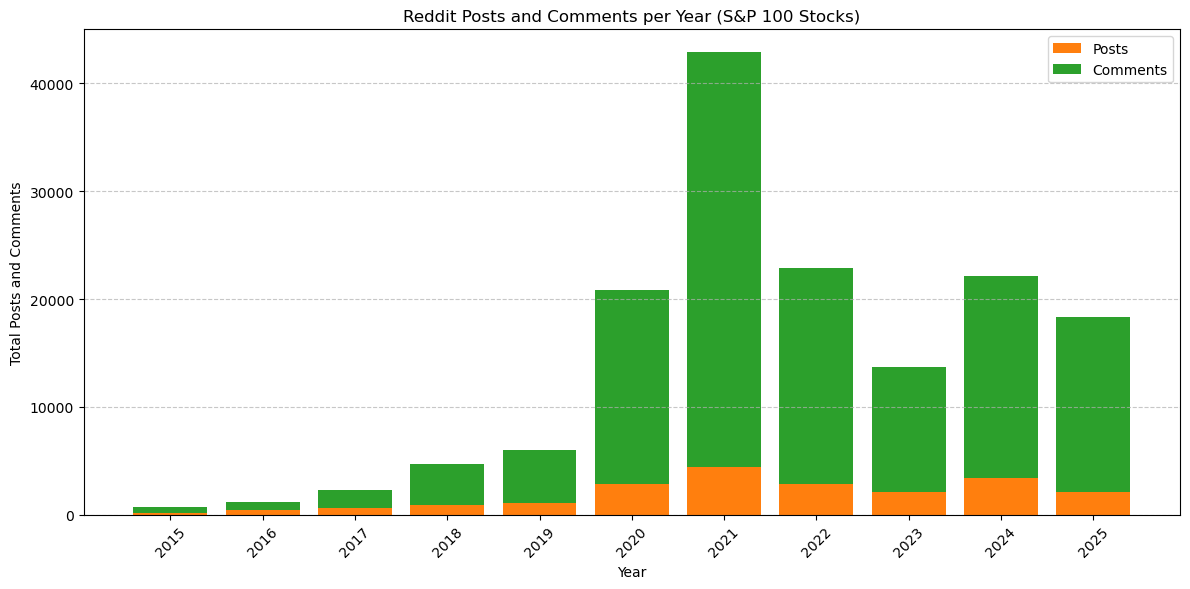

Saved side-by-side plot to S&P Updated/posts_comments_sidebyside_by_year.png


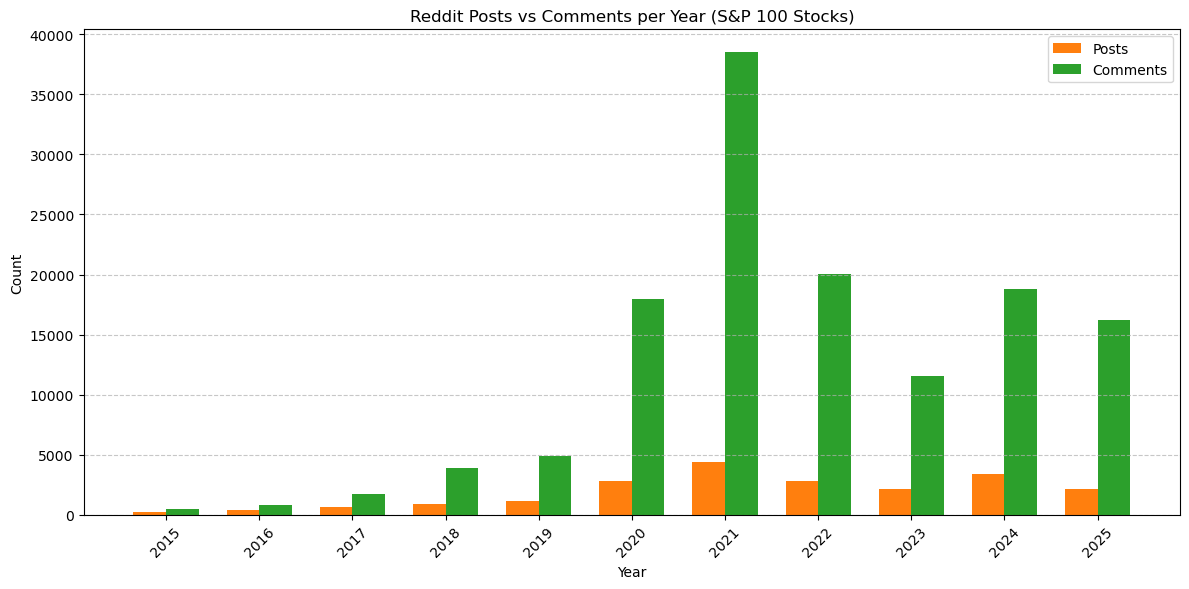


POSTS AND COMMENTS BY YEAR - DETAILED BREAKDOWN
 Year  Posts  Comments  Total  Posts %  Comments %
 2015    204       469    673     30.3        69.7
 2016    404       817   1221     33.1        66.9
 2017    646      1690   2336     27.7        72.3
 2018    875      3853   4728     18.5        81.5
 2019   1133      4907   6040     18.8        81.2
 2020   2844     17960  20804     13.7        86.3
 2021   4384     38494  42878     10.2        89.8
 2022   2818     20075  22893     12.3        87.7
 2023   2129     11540  13669     15.6        84.4
 2024   3393     18783  22176     15.3        84.7
 2025   2144     16178  18322     11.7        88.3

SUMMARY STATISTICS
Total Posts: 20,974
Total Comments: 134,766
Grand Total: 155,740
Posts Percentage: 13.5%
Comments Percentage: 86.5%

Year with Most Posts: 2021 (4,384 posts)
Year with Most Comments: 2021 (38,494 comments)
Year with Most Activity: 2021 (42,878 total)

Average Posts per Year: 1907
Average Comments per Year: 12251
Avera

In [33]:
try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Convert created_utc to datetime and extract year
    df['year'] = pd.to_datetime(df['created_utc']).dt.year
    
    # Separate posts and comments
    df_posts = df[df['type'] == 'post']
    df_comments = df[df['type'] == 'comment']
    
    # Count posts and comments per year
    posts_per_year = df_posts.groupby('year').size().reset_index(name='posts')
    comments_per_year = df_comments.groupby('year').size().reset_index(name='comments')
    total_per_year = df.groupby('year').size().reset_index(name='total')
    
    # Merge all data for comprehensive table
    yearly_data = posts_per_year.merge(comments_per_year, on='year', how='outer').fillna(0)
    yearly_data = yearly_data.merge(total_per_year, on='year', how='outer').fillna(0)
    
    # Convert to integers
    yearly_data['posts'] = yearly_data['posts'].astype(int)
    yearly_data['comments'] = yearly_data['comments'].astype(int)
    yearly_data['total'] = yearly_data['total'].astype(int)
    
    # --- Plot 1: Posts Only ---
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['year'], yearly_data['posts'], color='#ff7f0e')
    
    plt.xlabel('Year')
    plt.ylabel('Number of Posts')
    plt.title('Reddit Posts per Year (S&P 100 Stocks)')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(yearly_data['year'].astype(int), rotation=45)
    plt.tight_layout()
    
    # Save posts plot
    output_plot_posts = 'S&P Updated/posts_by_year.png'
    plt.savefig(output_plot_posts, dpi=300, bbox_inches='tight')
    print(f"Saved posts plot to {output_plot_posts}")
    plt.show()
    
    # --- Plot 2: Comments Only ---
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['year'], yearly_data['comments'], color='#2ca02c')
    
    plt.xlabel('Year')
    plt.ylabel('Number of Comments')
    plt.title('Reddit Comments per Year (S&P 100 Stocks)')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(yearly_data['year'].astype(int), rotation=45)
    plt.tight_layout()
    
    # Save comments plot
    output_plot_comments = 'S&P Updated/comments_by_year.png'
    plt.savefig(output_plot_comments, dpi=300, bbox_inches='tight')
    print(f"Saved comments plot to {output_plot_comments}")
    plt.show()
    
    # --- Plot 3: Combined (Stacked) ---
    plt.figure(figsize=(12, 6))
    
    # Create stacked bar chart
    width = 0.8
    plt.bar(yearly_data['year'], yearly_data['posts'], width, label='Posts', color='#ff7f0e')
    plt.bar(yearly_data['year'], yearly_data['comments'], width, bottom=yearly_data['posts'], 
            label='Comments', color='#2ca02c')
    
    plt.xlabel('Year')
    plt.ylabel('Total Posts and Comments')
    plt.title('Reddit Posts and Comments per Year (S&P 100 Stocks)')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(yearly_data['year'].astype(int), rotation=45)
    plt.tight_layout()
    
    # Save combined plot
    output_plot_combined = 'S&P Updated/posts_comments_combined_by_year.png'
    plt.savefig(output_plot_combined, dpi=300, bbox_inches='tight')
    print(f"Saved combined plot to {output_plot_combined}")
    plt.show()
    
    # --- Alternative Plot 3: Side-by-side bars ---
    plt.figure(figsize=(12, 6))
    
    x = yearly_data['year']
    width = 0.35
    
    plt.bar(x - width/2, yearly_data['posts'], width, label='Posts', color='#ff7f0e')
    plt.bar(x + width/2, yearly_data['comments'], width, label='Comments', color='#2ca02c')
    
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.title('Reddit Posts vs Comments per Year (S&P 100 Stocks)')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(yearly_data['year'].astype(int), rotation=45)
    plt.tight_layout()
    
    # Save side-by-side plot
    output_plot_sidebyside = 'S&P Updated/posts_comments_sidebyside_by_year.png'
    plt.savefig(output_plot_sidebyside, dpi=300, bbox_inches='tight')
    print(f"Saved side-by-side plot to {output_plot_sidebyside}")
    plt.show()
    
    # --- Print Summary Tables ---
    print("\n" + "="*60)
    print("POSTS AND COMMENTS BY YEAR - DETAILED BREAKDOWN")
    print("="*60)
    
    # Create formatted table
    summary_table = yearly_data.copy()
    summary_table['Posts %'] = (summary_table['posts'] / summary_table['total'] * 100).round(1)
    summary_table['Comments %'] = (summary_table['comments'] / summary_table['total'] * 100).round(1)
    
    # Rename columns for display
    display_table = summary_table[['year', 'posts', 'comments', 'total', 'Posts %', 'Comments %']].copy()
    display_table.columns = ['Year', 'Posts', 'Comments', 'Total', 'Posts %', 'Comments %']
    
    print(display_table.to_string(index=False))
    
    # --- Additional Statistics ---
    print(f"\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    total_posts = yearly_data['posts'].sum()
    total_comments = yearly_data['comments'].sum()
    total_all = yearly_data['total'].sum()
    
    print(f"Total Posts: {total_posts:,}")
    print(f"Total Comments: {total_comments:,}")
    print(f"Grand Total: {total_all:,}")
    print(f"Posts Percentage: {(total_posts/total_all*100):.1f}%")
    print(f"Comments Percentage: {(total_comments/total_all*100):.1f}%")
    
    print(f"\nYear with Most Posts: {yearly_data.loc[yearly_data['posts'].idxmax(), 'year']} ({yearly_data['posts'].max():,} posts)")
    print(f"Year with Most Comments: {yearly_data.loc[yearly_data['comments'].idxmax(), 'year']} ({yearly_data['comments'].max():,} comments)")
    print(f"Year with Most Activity: {yearly_data.loc[yearly_data['total'].idxmax(), 'year']} ({yearly_data['total'].max():,} total)")
    
    print(f"\nAverage Posts per Year: {yearly_data['posts'].mean():.0f}")
    print(f"Average Comments per Year: {yearly_data['comments'].mean():.0f}")
    print(f"Average Total per Year: {yearly_data['total'].mean():.0f}")
    
    # Posts to Comments Ratio
    print(f"\nOverall Posts to Comments Ratio: 1:{(total_comments/total_posts):.1f}")
    
except Exception as e:
    print(f"Error processing file: {e}")
    import traceback
    traceback.print_exc()

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_23684\1474981512.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_weights['Market Value'] = pd.to_numeric(df_weights['Market Value'].str.replace('[^\d.]', '', regex=True), errors='coerce')


Saved plot to S&P Updated/posts_comments_by_market_cap_descending.png on 2025-06-08 11:46:29 


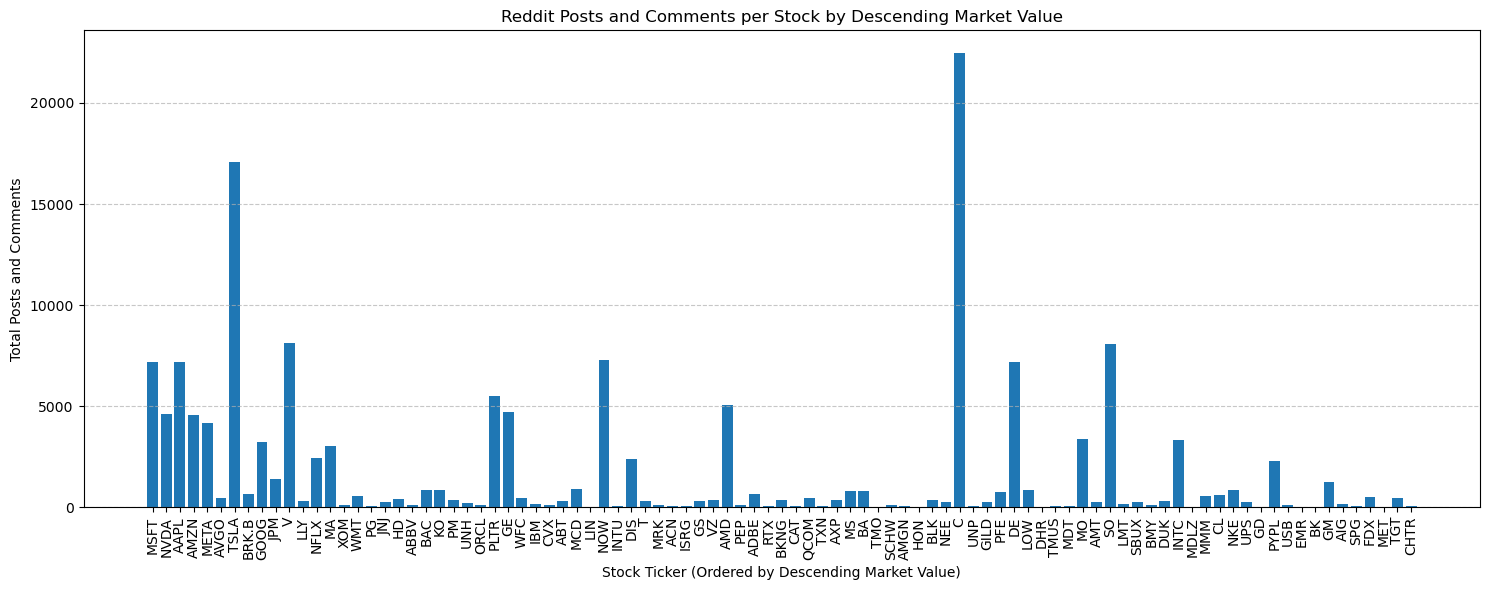

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Specify the CSV files (relative to /Algo/Thesis/)
sp100_file = 'sp100.csv'  # File with post/comment data
weights_file = 'Weights-05_25_2025.csv'  # File with market cap data

try:
    # Load CSV files
    df_sp100 = pd.read_csv(sp100_file)
    df_weights = pd.read_csv(weights_file)
    
    # Clean and convert 'Market Value' to numeric, handling errors
    df_weights['Market Value'] = pd.to_numeric(df_weights['Market Value'].str.replace('[^\d.]', '', regex=True), errors='coerce')
    
    # Merge datasets on 'Ticker' to assign market capitalization
    df_merged = df_sp100.groupby('ticker').size().reset_index(name='count').merge(
        df_weights[['Ticker', 'Market Value']], left_on='ticker', right_on='Ticker', how='left'
    )
    
    # Sort by market capitalization in descending order (largest to smallest)
    df_merged = df_merged.sort_values('Market Value', ascending=False)
    
    # Create bar chart
    plt.figure(figsize=(15, 6))  # Wider figure for many tickers
    plt.bar(range(len(df_merged)), df_merged['count'], color='#1f77b4')
    
    # Customize plot
    plt.xlabel('Stock Ticker (Ordered by Descending Market Value)')
    plt.ylabel('Total Posts and Comments')
    plt.title('Reddit Posts and Comments per Stock by Descending Market Value')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Set x-axis ticks and labels (tickers sorted by market cap)
    plt.xticks(range(len(df_merged)), df_merged['ticker'], rotation=90, ha='center')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save plot
    output_plot = 'S&P Updated/posts_comments_by_market_cap_descending.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_plot} on {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S %z')}")
    
    # Display plot
    plt.show()
    
    
except Exception as e:
    print(f"Error processing files: {e}")

## Posts and Comments by Stock

Visualize the distribution of Reddit posts and comments across different stocks.

Saved plot to S&P Updated/posts_comments_by_stock.png


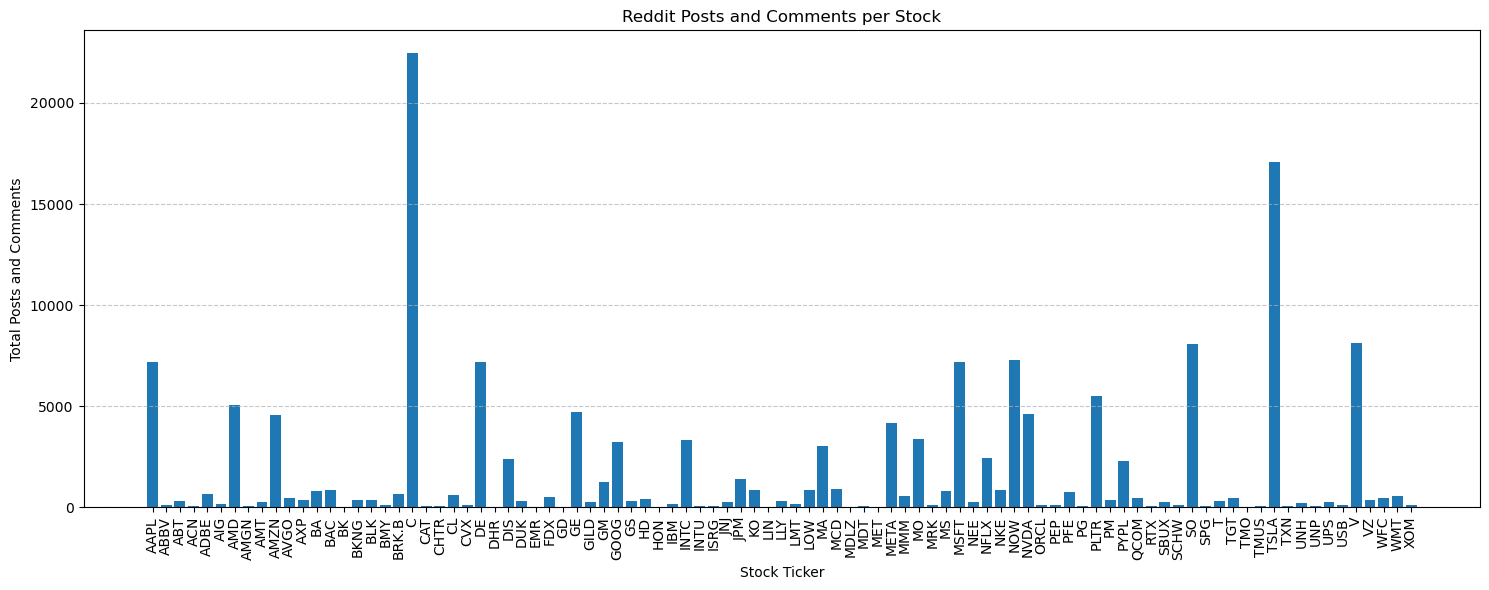


Posts and Comments per Stock:
   ticker  count
19      C  22470
82   TSLA  17068
88      V   8124
76     SO   8052
63    NOW   7297
..    ...    ...
30     GD     21
14     BK     12
45    LIN     10
28    EMR      7
37    HON      5

[93 rows x 2 columns]


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Specify the CSV file (relative to /Algo/Thesis/)
csv_file = 'sp100.csv'  # Replace with your CSV, e.g., 'S&P Updated/AMZN_updated.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Count posts and comments per ticker
    counts_per_ticker = df.groupby('ticker').size().reset_index(name='count')
    
    # Create bar chart
    plt.figure(figsize=(15, 6))  # Wider figure for many tickers
    plt.bar(counts_per_ticker['ticker'], counts_per_ticker['count'], color='#1f77b4')
    
    # Customize plot
    plt.xlabel('Stock Ticker')
    plt.ylabel('Total Posts and Comments')
    plt.title('Reddit Posts and Comments per Stock')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Rotate x-axis labels for readability
    plt.xticks(rotation=90, ha='center')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save plot
    output_plot = 'S&P Updated/posts_comments_by_stock.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_plot}")
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nPosts and Comments per Stock:")
    print(counts_per_ticker.sort_values('count', ascending=False))
    
except Exception as e:
    print(f"Error processing file: {e}")

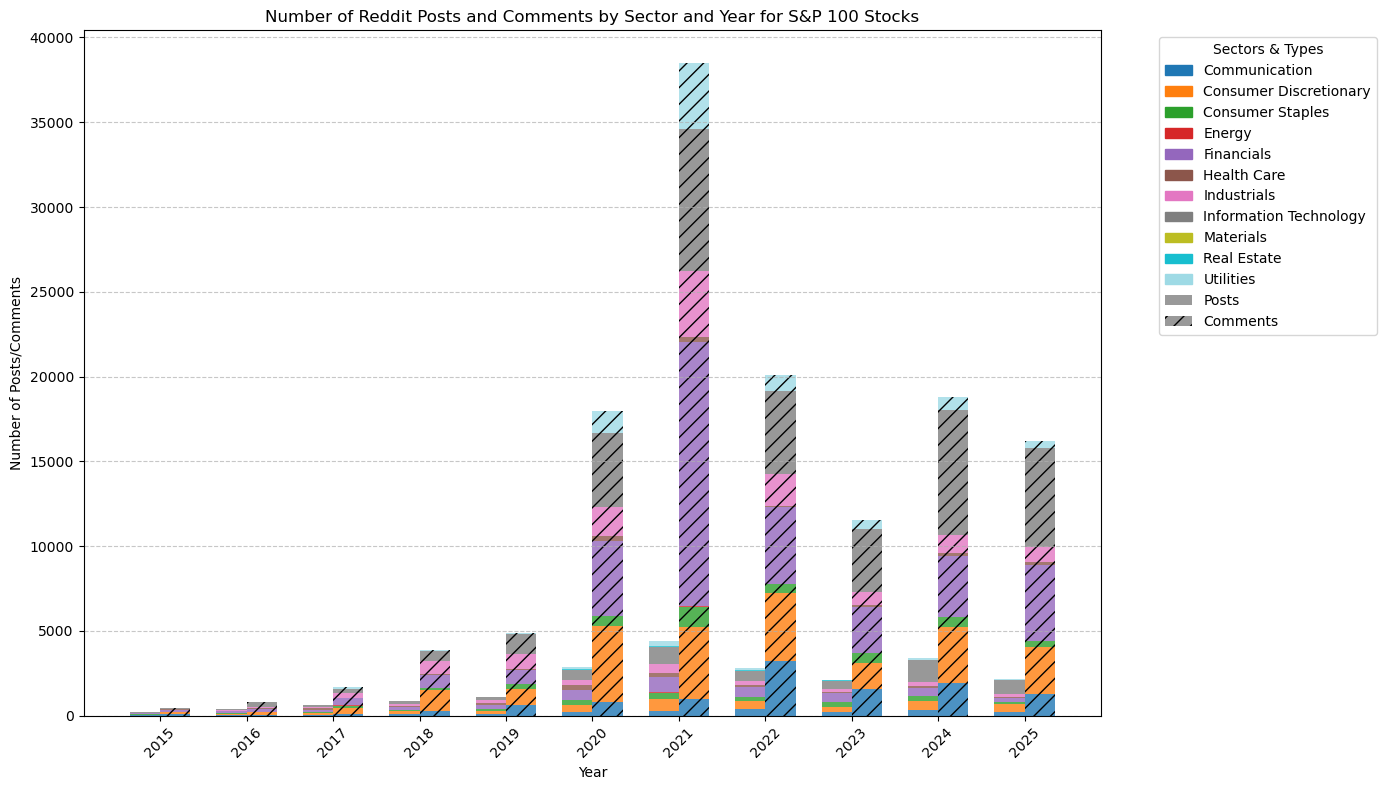


Sample of Counts by Sector, Year, and Type (first 10 rows):
          sector  year     type  count
0  Communication  2015     post   36.0
1  Communication  2015  comment   97.0
2  Communication  2016     post   45.0
3  Communication  2016  comment   56.0
4  Communication  2017     post   57.0
5  Communication  2017  comment  113.0
6  Communication  2018     post   91.0
7  Communication  2018  comment  275.0
8  Communication  2019     post  102.0
9  Communication  2019  comment  626.0

Total posts: 20974.0
Total comments: 134766.0
Sectors: 11
Years: 11
Rows with NaN sector or created_utc excluded: 0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Specify file path
data_file = 'sp100_sentiment_with_sector.csv'
output_plot = 'S&P Updated/sector_type_counts_by_year.png'

try:
    # Load dataset
    df = pd.read_csv(data_file)
    
    # Filter out invalid rows (NaN in sector or created_utc)
    df = df[df['sector'].notna() & df['created_utc'].notna()]
    
    # Convert created_utc to datetime and extract year
    df['created_utc'] = pd.to_datetime(df['created_utc'])
    df['year'] = df['created_utc'].dt.year
    
    # Filter for valid types (post or comment)
    df = df[df['type'].isin(['post', 'comment'])]
    
    # Group by sector, year, and type to count posts/comments
    counts = df.groupby(['sector', 'year', 'type']).size().unstack(fill_value=0).reset_index()
    
    # Ensure both post and comment columns exist
    if 'post' not in counts.columns:
        counts['post'] = 0
    if 'comment' not in counts.columns:
        counts['comment'] = 0
    
    # Get all sectors and years
    sectors = sorted(counts['sector'].unique())
    years = sorted(counts['year'].unique())
    
    # Create complete grid for all sector-year-type combinations
    all_combinations = pd.MultiIndex.from_product(
        [sectors, years, ['post', 'comment']],
        names=['sector', 'year', 'type']
    ).to_frame(index=False)
    
    # Merge with counts
    counts_long = counts.melt(id_vars=['sector', 'year'], value_vars=['post', 'comment'],
                             var_name='type', value_name='count')
    counts_full = all_combinations.merge(
        counts_long,
        on=['sector', 'year', 'type'],
        how='left'
    ).fillna({'count': 0})
    
    # Pivot for plotting
    counts_pivot = counts_full.pivot_table(
        index=['year', 'type'],
        columns='sector',
        values='count',
        fill_value=0
    )
    
    # --- Stacked Bar Chart ---
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot stacked bars for posts and comments per sector
    bar_width = 0.35
    x = np.arange(len(years))
    bottom_posts = np.zeros(len(years))
    bottom_comments = np.zeros(len(years))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))  # Distinct colors for sectors
    
    for idx, sector in enumerate(sectors):
        # Posts
        post_counts = counts_pivot.loc[(slice(None), 'post'), sector].values
        ax.bar(
            x - bar_width/2,
            post_counts,
            bar_width,
            bottom=bottom_posts,
            color=colors[idx],
            label=f'{sector} (Posts)' if idx == 0 else None,
            alpha=0.8
        )
        bottom_posts += post_counts
        
        # Comments
        comment_counts = counts_pivot.loc[(slice(None), 'comment'), sector].values
        ax.bar(
            x + bar_width/2,
            comment_counts,
            bar_width,
            bottom=bottom_comments,
            color=colors[idx],
            hatch='//',
            label=f'{sector} (Comments)' if idx == 0 else None,
            alpha=0.8
        )
        bottom_comments += comment_counts
    
    # Customize plot
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Posts/Comments')
    ax.set_title('Number of Reddit Posts and Comments by Sector and Year for S&P 100 Stocks')
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Create legend
    from matplotlib.patches import Patch
    sector_patches = [Patch(color=colors[i], label=sector) for i, sector in enumerate(sectors)]
    type_patches = [
        Patch(facecolor='gray', alpha=0.8, label='Posts'),
        Patch(facecolor='gray', hatch='//', alpha=0.8, label='Comments')
    ]
    ax.legend(handles=sector_patches + type_patches, title='Sectors & Types', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    # Save plot
    #plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    #print(f"Saved plot to {output_plot}")
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Counts by Sector, Year, and Type (first 10 rows):")
    print(counts_full.head(10))
    print(f"\nTotal posts: {counts_full[counts_full['type'] == 'post']['count'].sum()}")
    print(f"Total comments: {counts_full[counts_full['type'] == 'comment']['count'].sum()}")
    print(f"Sectors: {len(sectors)}")
    print(f"Years: {len(years)}")
    print(f"Rows with NaN sector or created_utc excluded: {len(pd.read_csv(data_file)) - len(df)}")
    
except Exception as e:
    print(f"Error processing file: {e}")

Saved plot to S&P Updated/unique_authors_by_creation_year.png


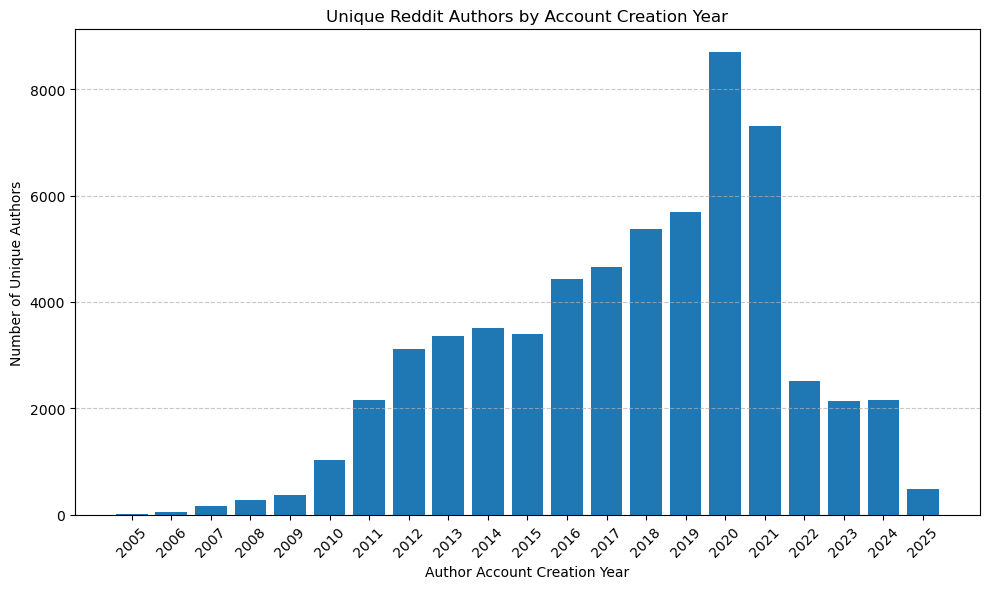


Unique Authors by Creation Year:
    year  count
0   2005      6
1   2006     59
2   2007    157
3   2008    271
4   2009    367
5   2010   1024
6   2011   2154
7   2012   3117
8   2013   3363
9   2014   3505
10  2015   3406
11  2016   4428
12  2017   4657
13  2018   5371
14  2019   5691
15  2020   8691
16  2021   7311
17  2022   2515
18  2023   2144
19  2024   2153
20  2025    491

Total unique authors: 60881
Rows with valid author_created_utc: 125101
Rows with missing/invalid author_created_utc or deleted authors: 30639


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Specify the CSV file (relative to /Algo/Thesis/)
csv_file = 'sp100.csv'  # Replace with your CSV, e.g., 'S&P Updated/AMZN_updated.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter out rows with empty, invalid, or deleted authors
    df_valid = df[
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # Get unique authors with their earliest author_created_utc
    unique_authors = df_valid.groupby('author')['author_created_utc'].first().reset_index()
    
    # Convert author_created_utc to datetime and extract year
    unique_authors['year'] = pd.to_datetime(unique_authors['author_created_utc']).dt.year
    
    # Count unique authors per year
    counts_per_year = unique_authors.groupby('year').size().reset_index(name='count')
    
    # Create bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(counts_per_year['year'], counts_per_year['count'], color='#1f77b4')
    
    # Customize plot
    plt.xlabel('Author Account Creation Year')
    plt.ylabel('Number of Unique Authors')
    plt.title('Unique Reddit Authors by Account Creation Year')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Ensure integer years on x-axis
    plt.xticks(counts_per_year['year'].astype(int), rotation=45)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save plot
    output_plot = 'S&P Updated/unique_authors_by_creation_year.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_plot}")
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nUnique Authors by Creation Year:")
    print(counts_per_year.sort_values('year'))
    print(f"\nTotal unique authors: {len(unique_authors)}")
    print(f"Rows with valid author_created_utc: {len(df_valid)}")
    print(f"Rows with missing/invalid author_created_utc or deleted authors: {len(df) - len(df_valid)}")
    
except Exception as e:
    print(f"Error processing file: {e}")

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_13840\2874924765.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_13840\2874924765.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_13840\2874924765.py:25: SettingWithCopyWarning: 
A v

Saved plot to S&P Updated/account_age_before_post.png


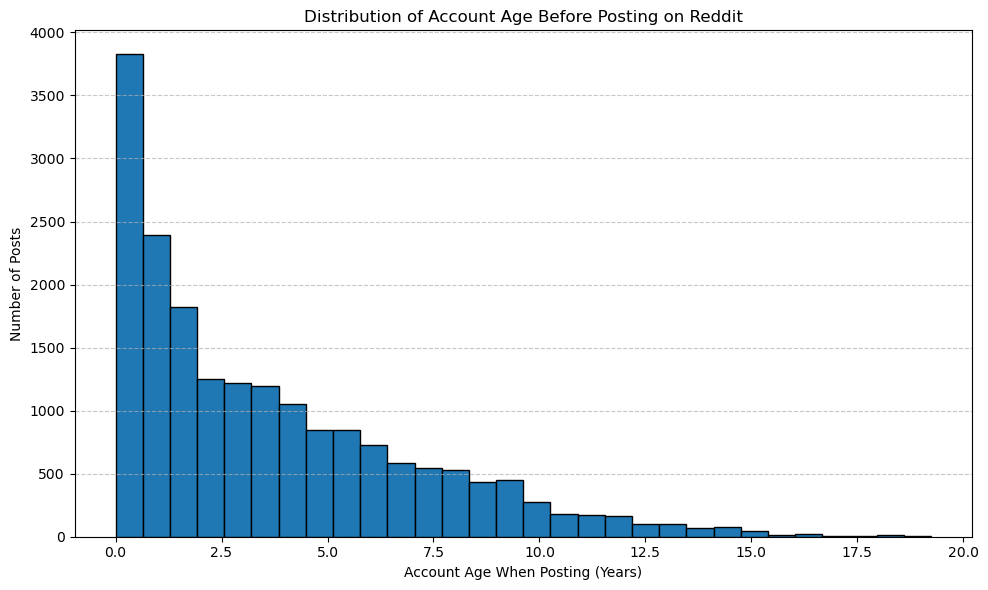


Summary of Account Age Before Posting (Years):
count    18951.000000
mean         3.641487
std          3.391285
min          0.000004
25%          0.873038
50%          2.653764
75%          5.552687
max         19.236204
Name: account_age_years, dtype: float64

Rows with valid posts and author_created_utc: 18951
Rows filtered out (comments, invalid author_created_utc, or deleted authors): 136789


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Specify the CSV file (relative to /Algo/Thesis/)
csv_file = 'sp100.csv'  # Replace with your CSV, e.g., 'S&P Updated/AMZN_updated.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter posts with valid author_created_utc and non-deleted authors
    df_valid = df[
        (df['type'] == 'post') &
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # Convert dates to datetime
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
    
    # Calculate time difference in days and convert to years
    df_valid['account_age_days'] = (df_valid['created_utc'] - df_valid['author_created_utc']).dt.total_seconds() / (60 * 60 * 24)
    df_valid['account_age_years'] = df_valid['account_age_days'] / 365.25
    
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(df_valid['account_age_years'], bins=30, color='#1f77b4', edgecolor='black')
    
    # Customize plot
    plt.xlabel('Account Age When Posting (Years)')
    plt.ylabel('Number of Posts')
    plt.title('Distribution of Account Age Before Posting on Reddit')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plot
    output_plot = 'S&P Updated/account_age_before_post.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_plot}")
    
    # Display plot
    plt.show()
    
    # Print summary statistics
    print("\nSummary of Account Age Before Posting (Years):")
    print(df_valid['account_age_years'].describe())
    print(f"\nRows with valid posts and author_created_utc: {len(df_valid)}")
    print(f"Rows filtered out (comments, invalid author_created_utc, or deleted authors): {len(df) - len(df_valid)}")
    
except Exception as e:
    print(f"Error processing file: {e}")

## Sentiment Distribution by Sector

Visualize how sentiment scores are distributed across different market sectors.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Specify the CSV file (relative to /Algo/Thesis/)
csv_file = 'sp100.csv'  # Replace with your CSV, e.g., 'S&P Updated/AMZN_updated.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter valid rows (exclude invalid author_created_utc and deleted authors)
    df_base = df[
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # --- Histogram 1: Comments Only ---
    # Filter comments
    df_comments = df_base[df_base['type'] == 'comment']
    
    # Convert dates to datetime
    df_comments['created_utc'] = pd.to_datetime(df_comments['created_utc'])
    df_comments['author_created_utc'] = pd.to_datetime(df_comments['author_created_utc'])
    
    # Calculate time difference in years
    df_comments['account_age_years'] = (
        df_comments['created_utc'] - df_comments['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Create histogram for comments
    plt.figure(figsize=(10, 6))
    plt.hist(df_comments['account_age_years'], bins=30, color='#1f77b4', edgecolor='black')
    
    # Customize plot
    plt.xlabel('Account Age When Commenting (Years)')
    plt.ylabel('Number of Comments')
    plt.title('Distribution of Account Age Before Commenting on Reddit')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save plot
    output_plot_comments = 'S&P Updated/account_age_before_comment.png'
    plt.savefig(output_plot_comments, dpi=300, bbox_inches='tight')
    print(f"Saved comments plot to {output_plot_comments}")
    
    # Display plot
    plt.show()
    
    # Print summary for comments
    print("\nSummary of Account Age Before Commenting (Years):")
    print(df_comments['account_age_years'].describe())
    print(f"\nRows with valid comments and author_created_utc: {len(df_comments)}")
    
    # --- Histogram 2: Posts and Comments Combined ---
    # Use all valid rows (posts + comments)
    df_all = df_base.copy()
    
    # Convert dates to datetime
    df_all['created_utc'] = pd.to_datetime(df_all['created_utc'])
    df_all['author_created_utc'] = pd.to_datetime(df_all['author_created_utc'])
    
    # Calculate time difference in years
    df_all['account_age_years'] = (
        df_all['created_utc'] - df_all['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Create histogram for all
    plt.figure(figsize=(10, 6))
    plt.hist(df_all['account_age_years'], bins=30, color='#1f77b4', edgecolor='black')
    
    # Customize plot
    plt.xlabel('Account Age When Contributing (Years)')
    plt.ylabel('Number of Posts and Comments')
    plt.title('Distribution of Account Age Before Posting or Commenting on Reddit')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save plot
    output_plot_all = 'S&P Updated/account_age_before_all.png'
    plt.savefig(output_plot_all, dpi=300, bbox_inches='tight')
    print(f"Saved posts and comments plot to {output_plot_all}")
    
    # Display plot
    plt.show()
    
    # Print summary for all
    print("\nSummary of Account Age Before Posting or Commenting (Years):")
    print(df_all['account_age_years'].describe())
    print(f"\nRows with valid posts/comments and author_created_utc: {len(df_all)}")
    print(f"Rows filtered out (invalid author_created_utc or deleted authors): {len(df) - len(df_all)}")
    
except Exception as e:
    print(f"Error processing file: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Specify the CSV file (relative to /Algo/Thesis/)
csv_file = 'GTLB/GTLB_Tech_Communities.csv'  # Replace with your CSV, e.g., 'S&P Updated/AMZN_updated.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter valid rows (exclude invalid author_created_utc and deleted authors)
    df_base = df[
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # --- Histogram 1: Comments Only ---
    # Filter comments
    df_comments = df_base[df_base['type'] == 'comment']
    
    # Convert dates to datetime
    df_comments['created_utc'] = pd.to_datetime(df_comments['created_utc'])
    df_comments['author_created_utc'] = pd.to_datetime(df_comments['author_created_utc'])
    
    # Calculate time difference in years
    df_comments['account_age_years'] = (
        df_comments['created_utc'] - df_comments['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Create histogram for comments
    plt.figure(figsize=(10, 6))
    plt.hist(df_comments['account_age_years'], bins=30, color='#1f77b4', edgecolor='black')
    
    # Customize plot
    plt.xlabel('Account Age When Commenting (Years)')
    plt.ylabel('Number of Comments')
    plt.title('Distribution of Account Age Before Commenting on Reddit')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save plot
    output_plot_comments = 'S&P Updated/account_age_before_comment.png'
    plt.savefig(output_plot_comments, dpi=300, bbox_inches='tight')
    print(f"Saved comments plot to {output_plot_comments}")
    
    # Display plot
    plt.show()
    
    # Print summary for comments
    print("\nSummary of Account Age Before Commenting (Years):")
    print(df_comments['account_age_years'].describe())
    print(f"\nRows with valid comments and author_created_utc: {len(df_comments)}")
    
    # --- Histogram 2: Posts and Comments Combined ---
    # Use all valid rows (posts + comments)
    df_all = df_base.copy()
    
    # Convert dates to datetime
    df_all['created_utc'] = pd.to_datetime(df_all['created_utc'])
    df_all['author_created_utc'] = pd.to_datetime(df_all['author_created_utc'])
    
    # Calculate time difference in years
    df_all['account_age_years'] = (
        df_all['created_utc'] - df_all['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Create histogram for all
    plt.figure(figsize=(10, 6))
    plt.hist(df_all['account_age_years'], bins=30, color='#1f77b4', edgecolor='black')
    
    # Customize plot
    plt.xlabel('Account Age When Contributing (Years)')
    plt.ylabel('Number of Posts and Comments')
    plt.title('Distribution of Account Age Before Posting or Commenting on Reddit')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save plot
    output_plot_all = 'S&P Updated/account_age_before_all.png'
    plt.savefig(output_plot_all, dpi=300, bbox_inches='tight')
    print(f"Saved posts and comments plot to {output_plot_all}")
    
    # Display plot
    plt.show()
    
    # Print summary for all
    print("\nSummary of Account Age Before Posting or Commenting (Years):")
    print(df_all['account_age_years'].describe())
    print(f"\nRows with valid posts/comments and author_created_utc: {len(df_all)}")
    print(f"Rows filtered out (invalid author_created_utc or deleted authors): {len(df) - len(df_all)}")
    
except Exception as e:
    print(f"Error processing file: {e}")

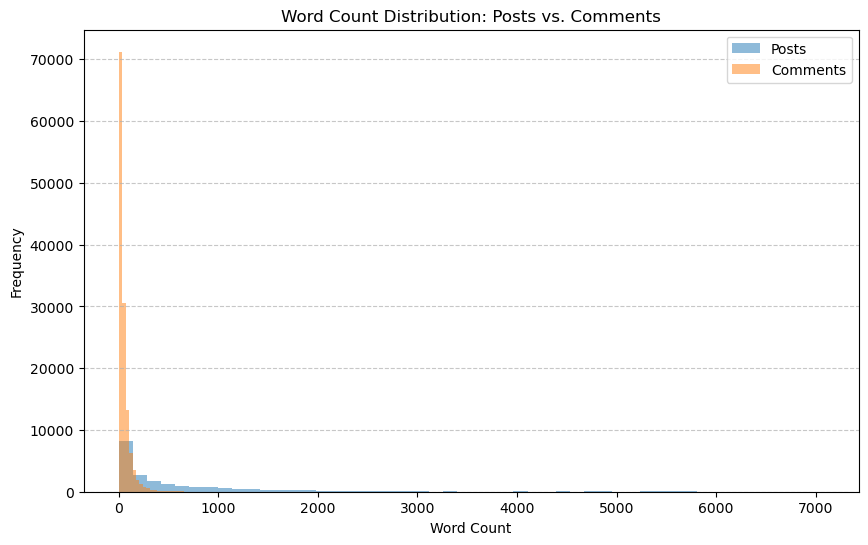

In [25]:
df_posts = df[df['type'] == 'post']['word_count']
df_comments = df[df['type'] == 'comment']['word_count']
plt.figure(figsize=(10, 6))
plt.hist(df_posts, bins=50, color='#1f77b4', alpha=0.5, label='Posts')
plt.hist(df_comments, bins=50, color='#ff7f0e', alpha=0.5, label='Comments')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Word Count Distribution: Posts vs. Comments')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig('S&P Updated/word_count_post_vs_comment.png', dpi=300)
plt.show()

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:22: SettingWithCopyWarning: 
A v

Total comments after filtering: 106150
Counting ticker mentions...


C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comments['ticker_mentions'] = df_comments.apply(count_ticker_mentions, axis=1)
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comments['age_bin'] = pd.cut(
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3803255484.py:71: FutureWarning: The default of observed=False is deprecated 

Saved bar chart to S&P Updated/account_age_vs_mean_upvotes_comments.png


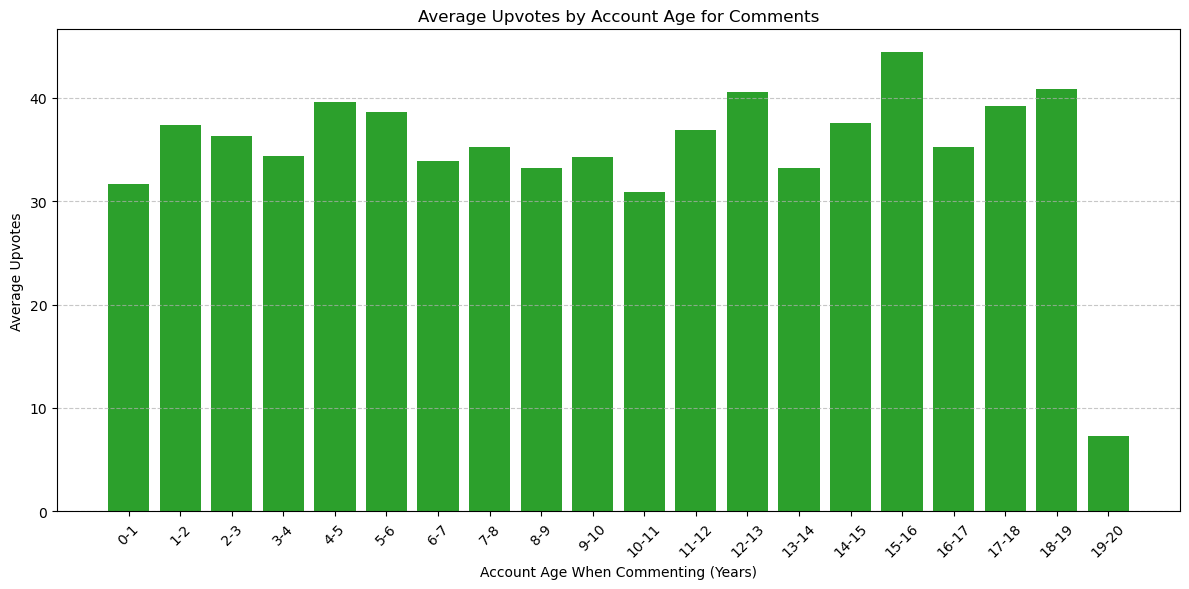

Saved bubble chart to S&P Updated/account_age_vs_upvotes_bubble_comments.png


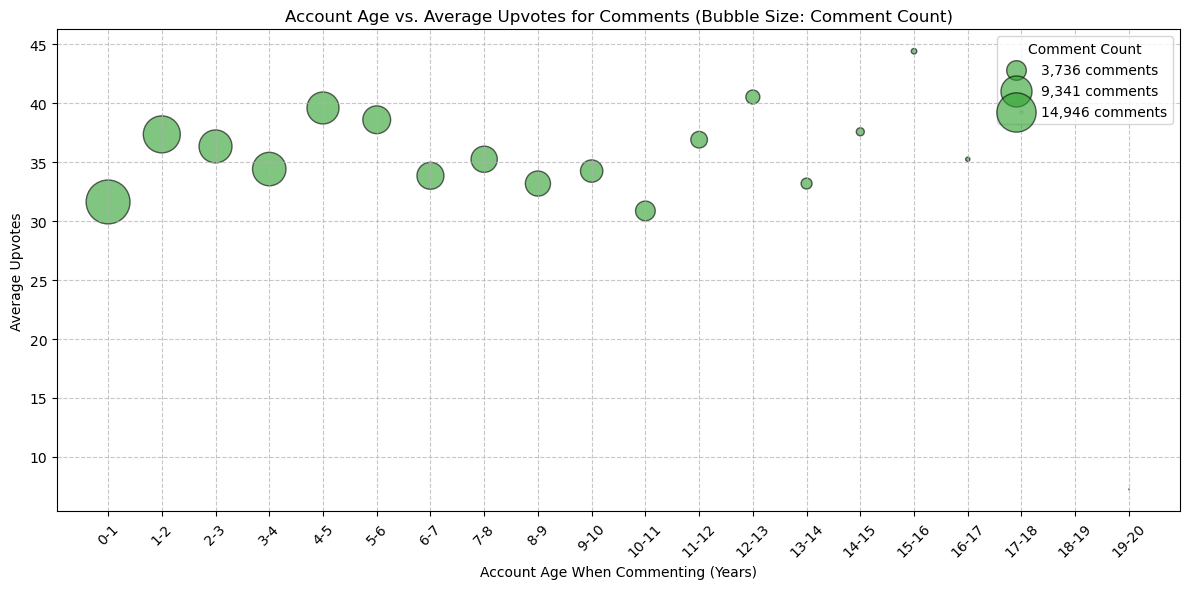

Saved additional plots to S&P Updated/account_age_word_count_ticker_mentions.png


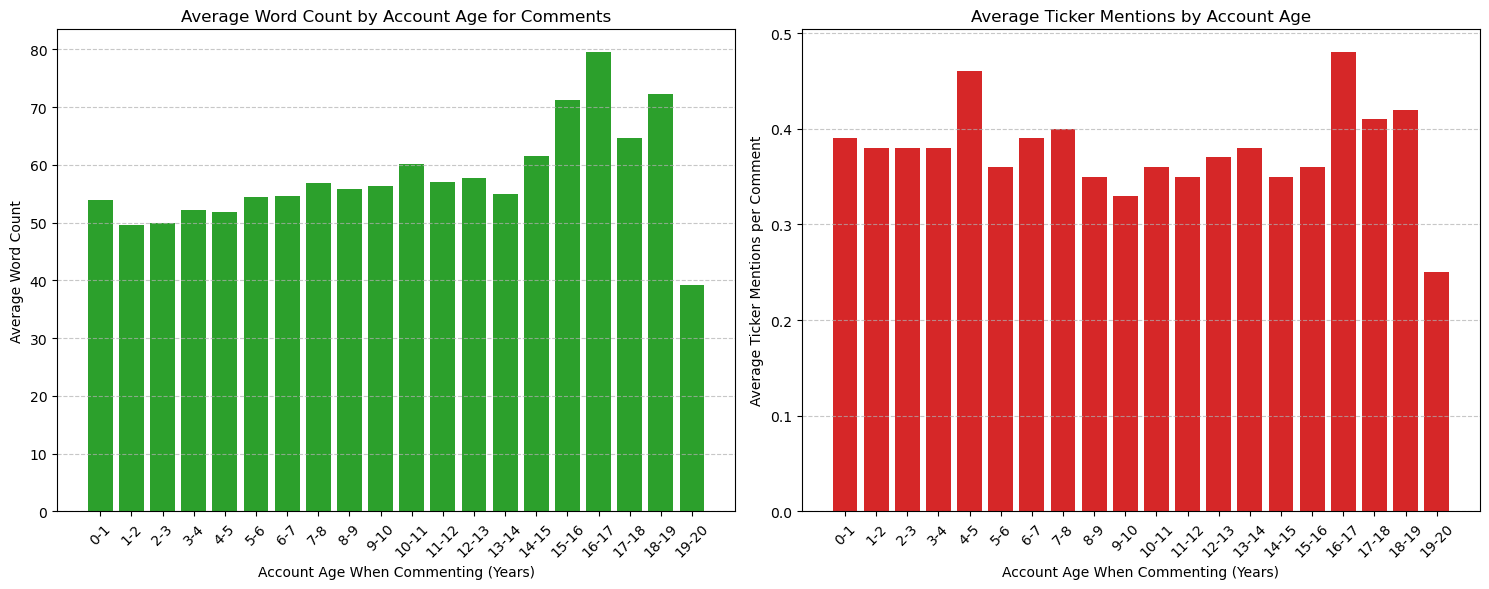


SUMMARY BY ACCOUNT AGE BIN (COMMENTS)
Age Bin (Years)  Comment Count  Avg Upvotes  Avg Word Count  Avg Ticker Mentions
            0-1          18683        31.62            53.9                 0.39
            1-2          13275        37.35            49.6                 0.38
            2-3          10531        36.33            49.9                 0.38
            3-4          10846        34.41            52.2                 0.38
            4-5           9925        39.59            51.8                 0.46
            5-6           7496        38.59            54.4                 0.36
            6-7           7054        33.84            54.6                 0.39
            7-8           6659        35.24            56.8                 0.40
            8-9           6128        33.18            55.8                 0.35
           9-10           4831        34.24            56.4                 0.33
          10-11           3754        30.86            60.1           

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

csv_file = 'sp100.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter valid rows (exclude invalid author_created_utc and deleted authors)
    df_valid = df[
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # Convert dates to datetime and calculate account age in years
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
    df_valid['account_age_years'] = (
        df_valid['created_utc'] - df_valid['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Ensure upvotes is numeric and non-negative
    df_valid['upvotes'] = pd.to_numeric(df_valid['upvotes'], errors='coerce').fillna(0).clip(lower=0)
    
    # Ensure word_count is numeric
    df_valid['word_count'] = pd.to_numeric(df_valid['word_count'], errors='coerce').fillna(0)
    
    # Filter COMMENTS (instead of posts)
    df_comments = df_valid[df_valid['type'] == 'comment']
    
    print(f"Total comments after filtering: {len(df_comments)}")
    
    # Function to count ticker mentions in text
    def count_ticker_mentions(row):
        if pd.isna(row['text']) or pd.isna(row['ticker']):
            return 0
        
        text = str(row['text']).upper()
        ticker = str(row['ticker']).upper()
        
        # Count exact word matches (not substrings)
        # Use word boundaries to avoid counting substrings
        pattern = r'\b' + re.escape(ticker) + r'\b'
        matches = len(re.findall(pattern, text))
        
        return matches
    
    # Count ticker mentions for each comment
    print("Counting ticker mentions...")
    df_comments['ticker_mentions'] = df_comments.apply(count_ticker_mentions, axis=1)
    
    # Bin account ages (1-year intervals)
    max_age = int(df_comments['account_age_years'].max()) + 1
    bins = np.arange(0, max_age + 1, 1)
    labels = [f'{i}-{i+1}' for i in range(max_age)]
    df_comments['age_bin'] = pd.cut(
        df_comments['account_age_years'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )
    
    # Remove any rows where age_bin is NaN (shouldn't happen but safety check)
    df_comments = df_comments.dropna(subset=['age_bin'])
    
    # Aggregate: mean upvotes, comment count, word count, and ticker mentions per bin
    agg_data = df_comments.groupby('age_bin').agg({
        'upvotes': 'mean',
        'id': 'count',  # Count comments
        'word_count': 'mean',  # Average word count
        'ticker_mentions': 'mean'  # Average ticker mentions per comment
    }).reset_index().rename(columns={
        'id': 'comment_count',
        'word_count': 'avg_word_count',
        'ticker_mentions': 'avg_ticker_mentions'
    })
    
    # Round for better display
    agg_data['upvotes'] = agg_data['upvotes'].round(2)
    agg_data['avg_word_count'] = agg_data['avg_word_count'].round(1)
    agg_data['avg_ticker_mentions'] = agg_data['avg_ticker_mentions'].round(2)
    
    # --- Bar Chart: Mean Upvotes by Account Age Bin (Comments) ---
    plt.figure(figsize=(12, 6))
    plt.bar(agg_data['age_bin'], agg_data['upvotes'], color='#2ca02c')
    
    # Customize bar chart
    plt.xlabel('Account Age When Commenting (Years)')
    plt.ylabel('Average Upvotes')
    plt.title('Average Upvotes by Account Age for Comments')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save bar chart
    output_plot_bar = 'S&P Updated/account_age_vs_mean_upvotes_comments.png'
    plt.savefig(output_plot_bar, dpi=300, bbox_inches='tight')
    print(f"Saved bar chart to {output_plot_bar}")
    
    # Display bar chart
    plt.show()
    
    # --- Bubble Chart: Account Age vs. Mean Upvotes with Comment Count ---
    plt.figure(figsize=(12, 6))
    
    # Scale bubble sizes
    bubble_scale = 1000
    max_comments = agg_data['comment_count'].max()
    sizes = agg_data['comment_count'] * bubble_scale / max_comments
    
    # Plot bubbles
    plt.scatter(
        range(len(agg_data)),  # Numeric x-axis for bins
        agg_data['upvotes'],
        s=sizes,  # Bubble size based on comment count
        c='#2ca02c',
        alpha=0.6,
        edgecolors='black'
    )
    
    # Customize bubble chart
    plt.xlabel('Account Age When Commenting (Years)')
    plt.ylabel('Average Upvotes')
    plt.title('Account Age vs. Average Upvotes for Comments (Bubble Size: Comment Count)')
    plt.xticks(range(len(agg_data)), agg_data['age_bin'], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Add legend for bubble sizes
    max_count = agg_data['comment_count'].max()
    legend_sizes = [int(max_count * 0.2), int(max_count * 0.5), int(max_count * 0.8)]
    legend_bubbles = [
        plt.scatter([], [], s=size * bubble_scale / max_count, c='#2ca02c', 
                   alpha=0.6, edgecolors='black', label=f'{size:,} comments')
        for size in legend_sizes if size > 0
    ]
    plt.legend(handles=legend_bubbles, title='Comment Count', loc='upper right')
    
    # Save bubble chart
    output_plot_bubble = 'S&P Updated/account_age_vs_upvotes_bubble_comments.png'
    plt.savefig(output_plot_bubble, dpi=300, bbox_inches='tight')
    print(f"Saved bubble chart to {output_plot_bubble}")
    
    # Display bubble chart
    plt.show()
    
    # --- Additional Visualization: Word Count and Ticker Mentions ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Average Word Count by Age Bin
    ax1.bar(agg_data['age_bin'], agg_data['avg_word_count'], color='#2ca02c')
    ax1.set_xlabel('Account Age When Commenting (Years)')
    ax1.set_ylabel('Average Word Count')
    ax1.set_title('Average Word Count by Account Age for Comments')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Plot 2: Average Ticker Mentions by Age Bin
    ax2.bar(agg_data['age_bin'], agg_data['avg_ticker_mentions'], color='#d62728')
    ax2.set_xlabel('Account Age When Commenting (Years)')
    ax2.set_ylabel('Average Ticker Mentions per Comment')
    ax2.set_title('Average Ticker Mentions by Account Age')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # Save additional plots
    output_plot_additional = 'S&P Updated/account_age_word_count_ticker_mentions.png'
    plt.savefig(output_plot_additional, dpi=300, bbox_inches='tight')
    print(f"Saved additional plots to {output_plot_additional}")
    
    plt.show()
    
    # --- Comprehensive Summary Table ---
    print("\n" + "="*80)
    print("SUMMARY BY ACCOUNT AGE BIN (COMMENTS)")
    print("="*80)
    
    # Create a formatted summary table
    summary_table = agg_data[[
        'age_bin', 'comment_count', 'upvotes', 'avg_word_count', 'avg_ticker_mentions'
    ]].copy()
    
    # Rename columns for better display
    summary_table.columns = [
        'Age Bin (Years)', 'Comment Count', 'Avg Upvotes', 
        'Avg Word Count', 'Avg Ticker Mentions'
    ]
    
    print(summary_table.to_string(index=False))
    
    # --- Additional Statistics ---
    print(f"\n" + "="*80)
    print("ADDITIONAL STATISTICS")
    print("="*80)
    
    print(f"Total valid comments analyzed: {len(df_comments):,}")
    print(f"Total rows filtered out: {len(df) - len(df_valid):,}")
    print(f"Age bins with data: {len(agg_data)}")
    
    print(f"\nOverall statistics:")
    print(f"  Average upvotes per comment: {df_comments['upvotes'].mean():.2f}")
    print(f"  Average word count per comment: {df_comments['word_count'].mean():.1f}")
    print(f"  Average ticker mentions per comment: {df_comments['ticker_mentions'].mean():.2f}")
    
    print(f"\nAccount age statistics:")
    print(f"  Minimum account age: {df_comments['account_age_years'].min():.1f} years")
    print(f"  Maximum account age: {df_comments['account_age_years'].max():.1f} years")
    print(f"  Average account age: {df_comments['account_age_years'].mean():.1f} years")
    print(f"  Median account age: {df_comments['account_age_years'].median():.1f} years")
    
    # Top age bins by different metrics
    print(f"\nTop 3 age bins by average upvotes:")
    top_upvotes = agg_data.nlargest(3, 'upvotes')[['age_bin', 'upvotes', 'comment_count']]
    for _, row in top_upvotes.iterrows():
        print(f"  {row['age_bin']} years: {row['upvotes']:.2f} upvotes ({row['comment_count']:,} comments)")
    
    print(f"\nTop 3 age bins by average word count:")
    top_words = agg_data.nlargest(3, 'avg_word_count')[['age_bin', 'avg_word_count', 'comment_count']]
    for _, row in top_words.iterrows():
        print(f"  {row['age_bin']} years: {row['avg_word_count']:.1f} words ({row['comment_count']:,} comments)")
    
    print(f"\nTop 3 age bins by average ticker mentions:")
    top_mentions = agg_data.nlargest(3, 'avg_ticker_mentions')[['age_bin', 'avg_ticker_mentions', 'comment_count']]
    for _, row in top_mentions.iterrows():
        print(f"  {row['age_bin']} years: {row['avg_ticker_mentions']:.2f} mentions ({row['comment_count']:,} comments)")
    
    # Save summary to CSV
    #output_csv = 'S&P Updated/comment_age_analysis_summary.csv'
    #agg_data.to_csv(output_csv, index=False)
    #print(f"\nSaved summary data to {output_csv}")

except Exception as e:
    print(f"Error processing file: {e}")
    import traceback
    traceback.print_exc()

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:22: SettingWithCopyWarning: 
A v

Total posts after filtering: 18951
Counting ticker mentions...


C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_posts['ticker_mentions'] = df_posts.apply(count_ticker_mentions, axis=1)
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_posts['age_bin'] = pd.cut(
C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_22100\3370371480.py:71: FutureWarning: The default of observed=False is deprecated and will 

Saved bar chart to S&P Updated/account_age_vs_mean_upvotes_posts.png


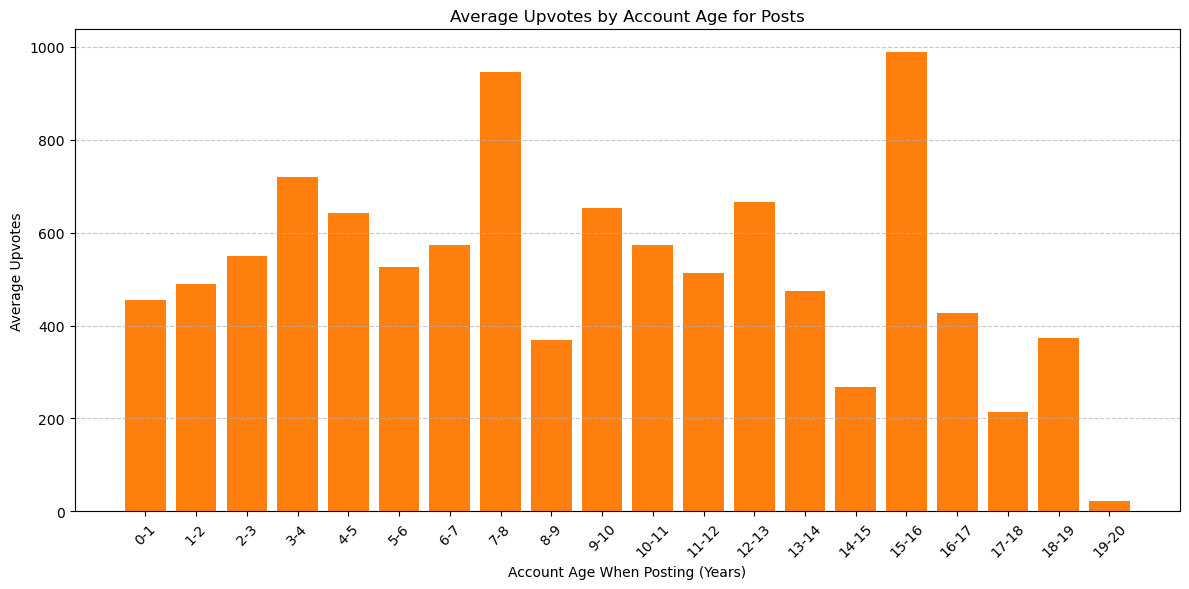

Saved bubble chart to S&P Updated/account_age_vs_upvotes_bubble_posts.png


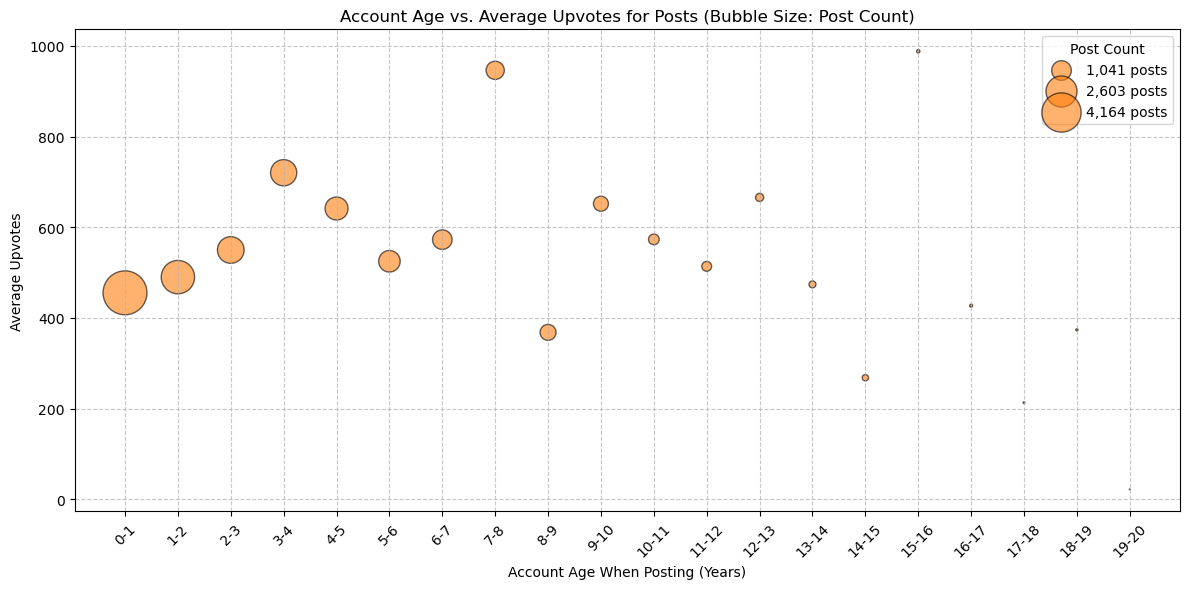

Saved additional plots to S&P Updated/account_age_word_count_ticker_mentions_posts.png


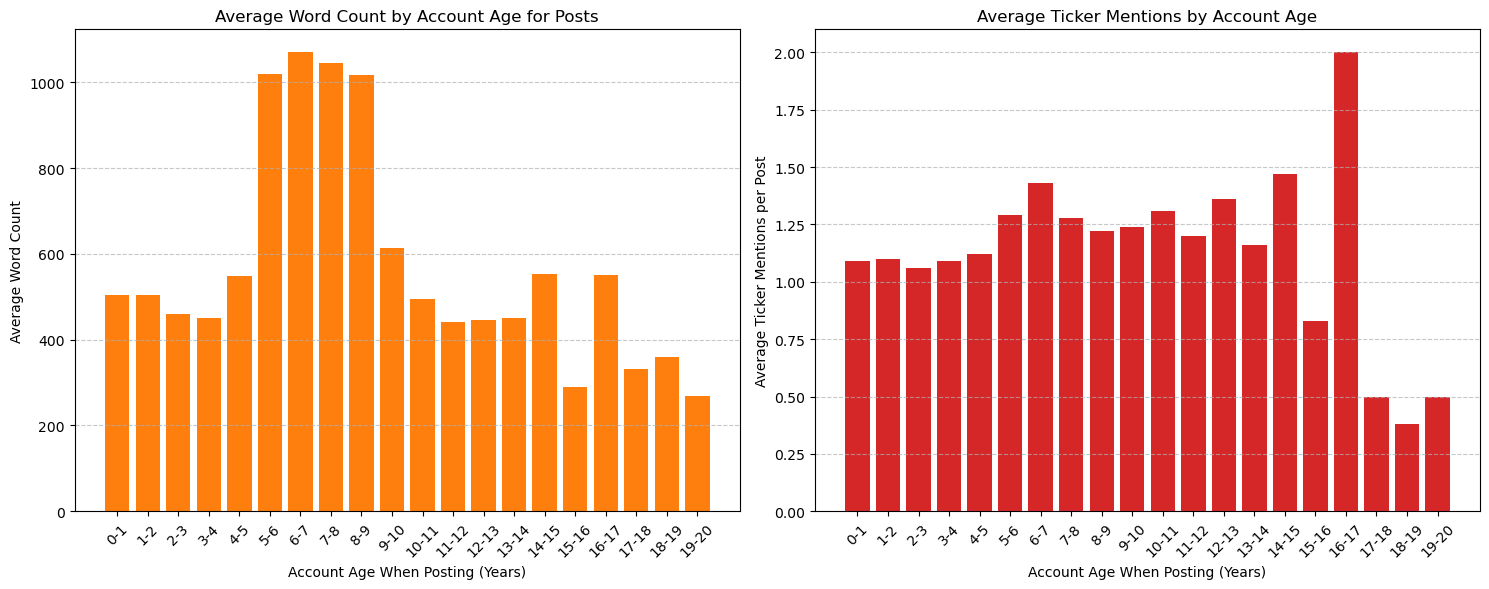


SUMMARY BY ACCOUNT AGE BIN (POSTS)
Age Bin (Years)  Post Count  Avg Upvotes  Avg Word Count  Avg Ticker Mentions
            0-1        5206       455.55           504.8                 1.09
            1-2        3008       490.15           503.6                 1.10
            2-3        1921       550.03           460.1                 1.06
            3-4        1858       720.42           450.6                 1.09
            4-5        1428       641.48           548.0                 1.12
            5-6        1252       525.12          1019.0                 1.29
            6-7        1029       572.85          1070.1                 1.43
            7-8         895       946.30          1045.5                 1.28
            8-9         688       368.26          1018.1                 1.22
           9-10         605       652.08           614.1                 1.24
          10-11         308       573.39           495.0                 1.31
          11-12         262 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

csv_file = 'sp100.csv'

try:
    # Load CSV
    df = pd.read_csv(csv_file)
    
    # Filter valid rows (exclude invalid author_created_utc and deleted authors)
    df_valid = df[
        df['author_created_utc'].notna() & 
        (df['author_created_utc'] != '') & 
        (df['author'] != '[deleted]')
    ]
    
    # Convert dates to datetime and calculate account age in years
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['author_created_utc'] = pd.to_datetime(df_valid['author_created_utc'])
    df_valid['account_age_years'] = (
        df_valid['created_utc'] - df_valid['author_created_utc']
    ).dt.total_seconds() / (60 * 60 * 24 * 365.25)
    
    # Ensure upvotes is numeric and non-negative
    df_valid['upvotes'] = pd.to_numeric(df_valid['upvotes'], errors='coerce').fillna(0).clip(lower=0)
    
    # Ensure word_count is numeric
    df_valid['word_count'] = pd.to_numeric(df_valid['word_count'], errors='coerce').fillna(0)
    
    # Filter POSTS (instead of comments)
    df_posts = df_valid[df_valid['type'] == 'post']
    
    print(f"Total posts after filtering: {len(df_posts)}")
    
    # Function to count ticker mentions in text
    def count_ticker_mentions(row):
        if pd.isna(row['text']) or pd.isna(row['ticker']):
            return 0
        
        text = str(row['text']).upper()
        ticker = str(row['ticker']).upper()
        
        # Count exact word matches (not substrings)
        # Use word boundaries to avoid counting substrings
        pattern = r'\b' + re.escape(ticker) + r'\b'
        matches = len(re.findall(pattern, text))
        
        return matches
    
    # Count ticker mentions for each post
    print("Counting ticker mentions...")
    df_posts['ticker_mentions'] = df_posts.apply(count_ticker_mentions, axis=1)
    
    # Bin account ages (1-year intervals)
    max_age = int(df_posts['account_age_years'].max()) + 1
    bins = np.arange(0, max_age + 1, 1)
    labels = [f'{i}-{i+1}' for i in range(max_age)]
    df_posts['age_bin'] = pd.cut(
        df_posts['account_age_years'], 
        bins=bins, 
        labels=labels, 
        include_lowest=True
    )
    
    # Remove any rows where age_bin is NaN (shouldn't happen but safety check)
    df_posts = df_posts.dropna(subset=['age_bin'])
    
    # Aggregate: mean upvotes, post count, word count, and ticker mentions per bin
    agg_data = df_posts.groupby('age_bin').agg({
        'upvotes': 'mean',
        'id': 'count',  # Count posts
        'word_count': 'mean',  # Average word count
        'ticker_mentions': 'mean'  # Average ticker mentions per post
    }).reset_index().rename(columns={
        'id': 'post_count',
        'word_count': 'avg_word_count',
        'ticker_mentions': 'avg_ticker_mentions'
    })
    
    # Round for better display
    agg_data['upvotes'] = agg_data['upvotes'].round(2)
    agg_data['avg_word_count'] = agg_data['avg_word_count'].round(1)
    agg_data['avg_ticker_mentions'] = agg_data['avg_ticker_mentions'].round(2)
    
    # --- Bar Chart: Mean Upvotes by Account Age Bin (Posts) ---
    plt.figure(figsize=(12, 6))
    plt.bar(agg_data['age_bin'], agg_data['upvotes'], color='#ff7f0e')
    
    # Customize bar chart
    plt.xlabel('Account Age When Posting (Years)')
    plt.ylabel('Average Upvotes')
    plt.title('Average Upvotes by Account Age for Posts')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save bar chart
    output_plot_bar = 'S&P Updated/account_age_vs_mean_upvotes_posts.png'
    plt.savefig(output_plot_bar, dpi=300, bbox_inches='tight')
    print(f"Saved bar chart to {output_plot_bar}")
    
    # Display bar chart
    plt.show()
    
    # --- Bubble Chart: Account Age vs. Mean Upvotes with Post Count ---
    plt.figure(figsize=(12, 6))
    
    # Scale bubble sizes
    bubble_scale = 1000
    max_posts = agg_data['post_count'].max()
    sizes = agg_data['post_count'] * bubble_scale / max_posts
    
    # Plot bubbles
    plt.scatter(
        range(len(agg_data)),  # Numeric x-axis for bins
        agg_data['upvotes'],
        s=sizes,  # Bubble size based on post count
        c='#ff7f0e',
        alpha=0.6,
        edgecolors='black'
    )
    
    # Customize bubble chart
    plt.xlabel('Account Age When Posting (Years)')
    plt.ylabel('Average Upvotes')
    plt.title('Account Age vs. Average Upvotes for Posts (Bubble Size: Post Count)')
    plt.xticks(range(len(agg_data)), agg_data['age_bin'], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Add legend for bubble sizes
    max_count = agg_data['post_count'].max()
    legend_sizes = [int(max_count * 0.2), int(max_count * 0.5), int(max_count * 0.8)]
    legend_bubbles = [
        plt.scatter([], [], s=size * bubble_scale / max_count, c='#ff7f0e', 
                   alpha=0.6, edgecolors='black', label=f'{size:,} posts')
        for size in legend_sizes if size > 0
    ]
    plt.legend(handles=legend_bubbles, title='Post Count', loc='upper right')
    
    # Save bubble chart
    output_plot_bubble = 'S&P Updated/account_age_vs_upvotes_bubble_posts.png'
    plt.savefig(output_plot_bubble, dpi=300, bbox_inches='tight')
    print(f"Saved bubble chart to {output_plot_bubble}")
    
    # Display bubble chart
    plt.show()
    
    # --- Additional Visualization: Word Count and Ticker Mentions ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Average Word Count by Age Bin
    ax1.bar(agg_data['age_bin'], agg_data['avg_word_count'], color='#ff7f0e')
    ax1.set_xlabel('Account Age When Posting (Years)')
    ax1.set_ylabel('Average Word Count')
    ax1.set_title('Average Word Count by Account Age for Posts')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Plot 2: Average Ticker Mentions by Age Bin
    ax2.bar(agg_data['age_bin'], agg_data['avg_ticker_mentions'], color='#d62728')
    ax2.set_xlabel('Account Age When Posting (Years)')
    ax2.set_ylabel('Average Ticker Mentions per Post')
    ax2.set_title('Average Ticker Mentions by Account Age')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # Save additional plots
    output_plot_additional = 'S&P Updated/account_age_word_count_ticker_mentions_posts.png'
    plt.savefig(output_plot_additional, dpi=300, bbox_inches='tight')
    print(f"Saved additional plots to {output_plot_additional}")
    
    plt.show()
    
    # --- Comprehensive Summary Table ---
    print("\n" + "="*80)
    print("SUMMARY BY ACCOUNT AGE BIN (POSTS)")
    print("="*80)
    
    # Create a formatted summary table
    summary_table = agg_data[[
        'age_bin', 'post_count', 'upvotes', 'avg_word_count', 'avg_ticker_mentions'
    ]].copy()
    
    # Rename columns for better display
    summary_table.columns = [
        'Age Bin (Years)', 'Post Count', 'Avg Upvotes', 
        'Avg Word Count', 'Avg Ticker Mentions'
    ]
    
    print(summary_table.to_string(index=False))
    
    # --- Additional Statistics ---
    print(f"\n" + "="*80)
    print("ADDITIONAL STATISTICS")
    print("="*80)
    
    print(f"Total valid posts analyzed: {len(df_posts):,}")
    print(f"Total rows filtered out: {len(df) - len(df_valid):,}")
    print(f"Age bins with data: {len(agg_data)}")
    
    print(f"\nOverall statistics:")
    print(f"  Average upvotes per post: {df_posts['upvotes'].mean():.2f}")
    print(f"  Average word count per post: {df_posts['word_count'].mean():.1f}")
    print(f"  Average ticker mentions per post: {df_posts['ticker_mentions'].mean():.2f}")
    
    print(f"\nAccount age statistics:")
    print(f"  Minimum account age: {df_posts['account_age_years'].min():.1f} years")
    print(f"  Maximum account age: {df_posts['account_age_years'].max():.1f} years")
    print(f"  Average account age: {df_posts['account_age_years'].mean():.1f} years")
    print(f"  Median account age: {df_posts['account_age_years'].median():.1f} years")
    
    # Top age bins by different metrics
    print(f"\nTop 3 age bins by average upvotes:")
    top_upvotes = agg_data.nlargest(3, 'upvotes')[['age_bin', 'upvotes', 'post_count']]
    for _, row in top_upvotes.iterrows():
        print(f"  {row['age_bin']} years: {row['upvotes']:.2f} upvotes ({row['post_count']:,} posts)")
    
    print(f"\nTop 3 age bins by average word count:")
    top_words = agg_data.nlargest(3, 'avg_word_count')[['age_bin', 'avg_word_count', 'post_count']]
    for _, row in top_words.iterrows():
        print(f"  {row['age_bin']} years: {row['avg_word_count']:.1f} words ({row['post_count']:,} posts)")
    
    print(f"\nTop 3 age bins by average ticker mentions:")
    top_mentions = agg_data.nlargest(3, 'avg_ticker_mentions')[['age_bin', 'avg_ticker_mentions', 'post_count']]
    for _, row in top_mentions.iterrows():
        print(f"  {row['age_bin']} years: {row['avg_ticker_mentions']:.2f} mentions ({row['post_count']:,} posts)")
    
    # Save summary to CSV
    #output_csv = 'S&P Updated/post_age_analysis_summary.csv'
    #agg_data.to_csv(output_csv, index=False)
    #print(f"\nSaved summary data to {output_csv}")

except Exception as e:
    print(f"Error processing file: {e}")
    import traceback
    traceback.print_exc()

In [35]:
csv_file = 'sp100_sentiment_with_sector.csv'
cs = pd.read_csv(csv_file)
cs.columns

Index(['ticker', 'sector', 'type', 'id', 'parent_post_id', 'subreddit',
       'title', 'text', 'url', 'upvotes', 'created_utc', 'author',
       'word_count', 'author_created_utc', 'sentiment_positive',
       'sentiment_neutral', 'sentiment_negative', 'sentiment_compound'],
      dtype='object')

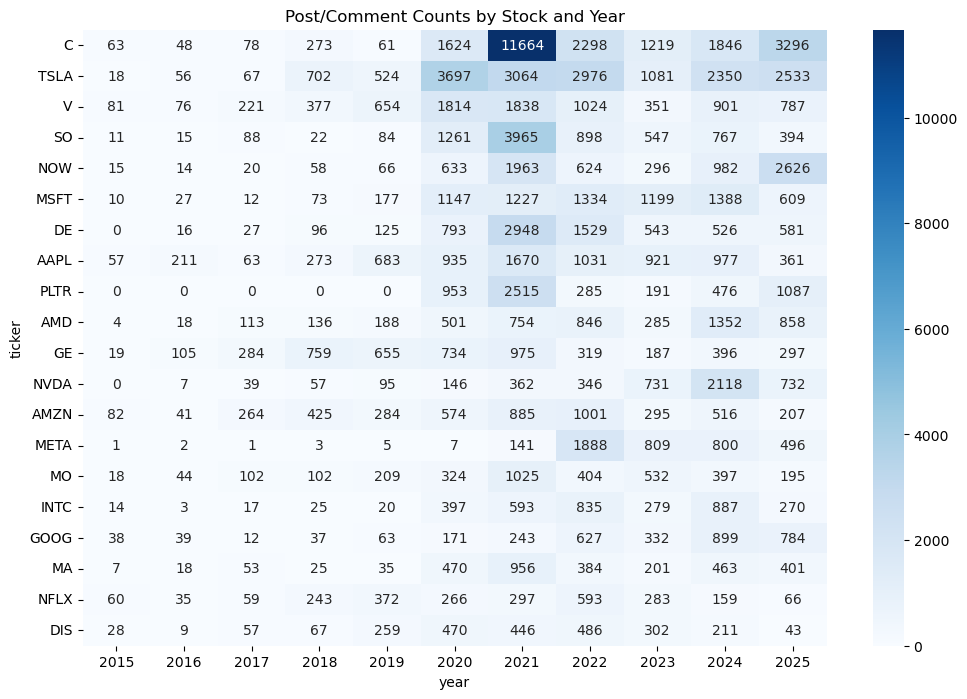

In [45]:
import seaborn as sns
df['year'] = pd.to_datetime(df['created_utc']).dt.year
pivot = df.pivot_table(index='ticker', columns='year', values='id', aggfunc='count', fill_value=0)
top_tickers = df['ticker'].value_counts().head(20).index
pivot = pivot.loc[top_tickers]
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='d')
plt.title('Post/Comment Counts by Stock and Year')
plt.savefig('S&P Updated/activity_heatmap.png', dpi=300)
plt.show()

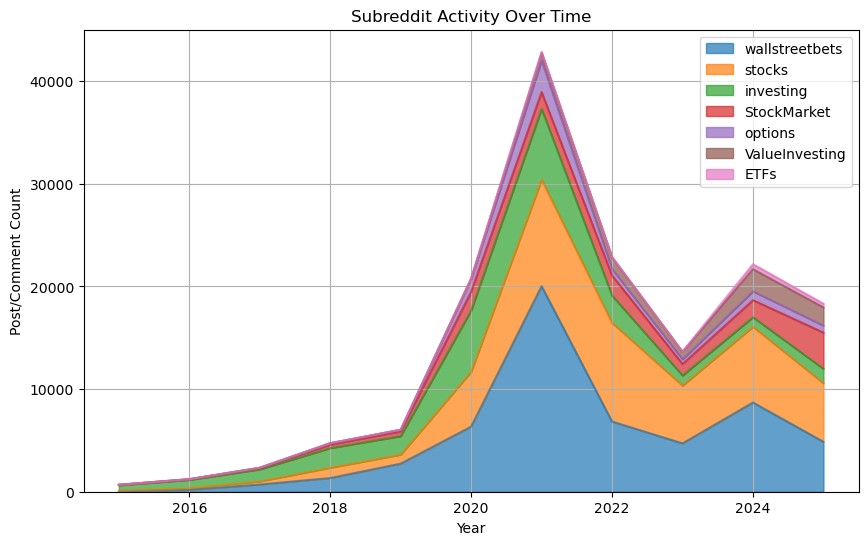

In [3]:
df['year'] = pd.to_datetime(df['created_utc']).dt.year
counts = df.groupby(['year', 'subreddit']).size().unstack(fill_value=0)
top_subreddits = df['subreddit'].value_counts().index
counts = counts[top_subreddits]
counts.plot(kind='area', stacked=True, figsize=(10, 6), alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Post/Comment Count')
plt.title('Subreddit Activity Over Time')
plt.legend()
plt.grid(True)
plt.savefig('S&P Updated/subreddit_activity_over_time.png', dpi=300)
plt.show()